# Experiment 5 — conservative LightGBM and XGBoost tuning
Exact Experiment 4 features and folds. A small documented neighborhood search with no feature changes, leaderboard selection, or brute-force grid.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
lgb = pd.read_csv(ROOT / 'reports/lightgbm_tuning.csv')
xgb = pd.read_csv(ROOT / 'reports/xgboost_tuning.csv')
blends = pd.read_csv(ROOT / 'reports/tuned_blend_results.csv')
analysis = json.loads((ROOT / 'reports/tuning_analysis.json').read_text())

The full run is reproducible with `uv run tune-boosters`. Candidate OOF vectors are checkpointed so family searches are resumable. Tuned candidates use fold-local AUC early stopping with 75 rounds; both selected models effectively reach the tested 1,200-tree cap.

## LightGBM candidates

In [2]:
columns = [
    'candidate', 'oof_auc', 'log_loss', 'delta_vs_e4_component',
    'mean_fold_auc', 'std_fold_auc', 'fit_seconds', 'predict_seconds',
    'mean_best_iteration', 'fold_1_auc', 'fold_2_auc', 'fold_3_auc', 'fold_4_auc', 'fold_5_auc'
]
lgb[columns].sort_values('oof_auc', ascending=False).style.format({
    c: '{:.6f}' for c in columns if c not in ['candidate', 'mean_best_iteration']
})

,candidate,oof_auc,log_loss,delta_vs_e4_component,mean_fold_auc,std_fold_auc,fit_seconds,predict_seconds,mean_best_iteration,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc
4,wide_leaves_63,0.963223,0.221984,0.002426,0.963224,0.000705,82.989322,5.313139,1199.400000,0.962260,0.963072,0.963582,0.964161,0.963048
5,regularized_children,0.963026,0.222990,0.002228,0.963027,0.000645,58.007656,5.275209,1200.000000,0.962112,0.962890,0.963424,0.963822,0.962887
7,shallow_regularized,0.962954,0.223432,0.002157,0.962956,0.000593,47.327354,3.457698,1199.600000,0.962270,0.962818,0.963204,0.963832,0.962658
2,slow_lr_003,0.962737,0.223947,0.001940,0.962737,0.000689,78.931189,7.808053,1800.000000,0.961779,0.962631,0.963039,0.963661,0.962574
1,slow_lr_005,0.962690,0.224026,0.001892,0.962688,0.000785,51.752091,4.614535,1121.000000,0.961578,0.962652,0.963217,0.963615,0.962380
6,row_col_sampling,0.962422,0.225023,0.001624,0.962417,0.001184,46.614995,4.076905,902.000000,0.961058,0.962155,0.963354,0.963894,0.961624
3,compact_leaves_15,0.961325,0.228588,0.000528,0.961326,0.000668,35.191561,3.819158,1150.800000,0.960641,0.961059,0.961726,0.962286,0.960919
0,e4_baseline,0.960797,0.233728,0.000000,0.960798,0.000628,13.887888,1.609338,300.000000,0.960139,0.960652,0.960627,0.961841,0.960731


The selected 63-leaf candidate is numerically best, while slower-learning and regularized neighbors also improve substantially. This is a broad parameter pattern rather than a single isolated win.

## XGBoost candidates

In [3]:
xgb[columns].sort_values('oof_auc', ascending=False).style.format({
    c: '{:.6f}' for c in columns if c not in ['candidate', 'mean_best_iteration']
})

,candidate,oof_auc,log_loss,delta_vs_e4_component,mean_fold_auc,std_fold_auc,fit_seconds,predict_seconds,mean_best_iteration,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc
5,depth_7,0.963705,0.220501,0.002800,0.963706,0.000559,127.375838,1.652164,1199.600000,0.963008,0.963663,0.963890,0.964520,0.963448
7,row_col_sampling,0.963672,0.221083,0.002767,0.963674,0.000600,125.281718,1.505731,1199.000000,0.962878,0.963633,0.963898,0.964513,0.963447
6,regularized,0.963414,0.221875,0.002509,0.963416,0.000617,121.221765,1.397903,1199.800000,0.962596,0.963316,0.963670,0.964275,0.963225
1,slow_lr_005,0.963392,0.221897,0.002487,0.963393,0.000664,122.353189,1.473171,1198.600000,0.962480,0.963253,0.963753,0.964259,0.963217
8,gamma_01,0.963377,0.221924,0.002472,0.963378,0.000612,119.064803,1.403884,1199.600000,0.962660,0.963273,0.963628,0.964276,0.963055
2,slow_lr_003,0.963115,0.222882,0.002210,0.963116,0.000676,178.673436,2.098803,1799.800000,0.962184,0.963034,0.963323,0.964059,0.962978
4,depth_5,0.962468,0.225047,0.001563,0.962470,0.000636,111.889458,1.094527,1200.000000,0.961613,0.962392,0.962906,0.963251,0.962186
0,e4_baseline,0.960905,0.230040,0.000000,0.960907,0.000675,11.981247,0.399792,300.000000,0.960006,0.960748,0.961155,0.961859,0.960769
3,depth_4,0.960490,0.231259,-0.000415,0.960491,0.000664,109.497056,0.807588,1200.000000,0.959601,0.960372,0.960752,0.961416,0.960315


Depth 7 is selected, closely supported by row/column sampling, regularization, gamma, and the plain slower-learning candidate. Depth 4 underfits at the tested cap; depth 5 improves but trails depth 6–7.

## Simple tuned and mixed blends

In [4]:
blends.sort_values('oof_auc', ascending=False).head(20).style.format({
    'left_weight': '{:.1f}', 'right_weight': '{:.1f}',
    'oof_auc': '{:.6f}', 'log_loss': '{:.6f}', 'delta_vs_e4_blend': '{:+.6f}'
})

,blend_type,left_model,right_model,left_weight,right_weight,oof_auc,log_loss,delta_vs_e4_blend
4,tuned_pair,tuned_lightgbm,tuned_xgboost,0.4,0.6,0.963972,0.219879,+0.002646
3,tuned_pair,tuned_lightgbm,tuned_xgboost,0.3,0.7,0.963963,0.219880,+0.002637
5,tuned_pair,tuned_lightgbm,tuned_xgboost,0.5,0.5,0.963943,0.219974,+0.002617
2,tuned_pair,tuned_lightgbm,tuned_xgboost,0.2,0.8,0.963916,0.219979,+0.002590
6,tuned_pair,tuned_lightgbm,tuned_xgboost,0.6,0.4,0.963878,0.220163,+0.002552
1,tuned_pair,tuned_lightgbm,tuned_xgboost,0.1,0.9,0.963831,0.220183,+0.002505
7,tuned_pair,tuned_lightgbm,tuned_xgboost,0.7,0.3,0.963774,0.220449,+0.002448
0,tuned_pair,tuned_lightgbm,tuned_xgboost,0.0,1.0,0.963705,0.220501,+0.002379
22,e4_lgb_tuned_xgb,e4_lightgbm,tuned_xgboost,0.0,1.0,0.963705,0.220501,+0.002379
23,e4_lgb_tuned_xgb,e4_lightgbm,tuned_xgboost,0.1,0.9,0.963696,0.220686,+0.002370


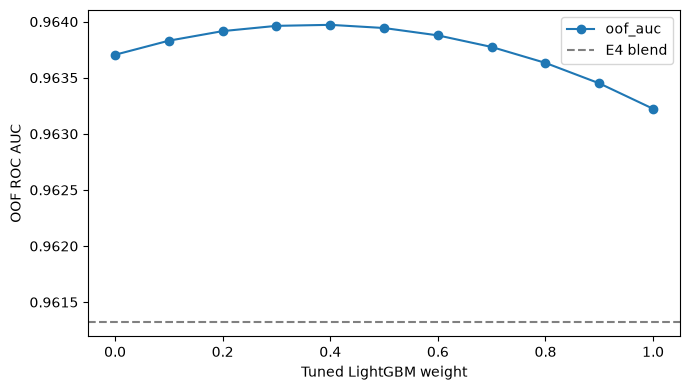

In [5]:
curve = blends[blends['blend_type'] == 'tuned_pair']
ax = curve.plot(x='left_weight', y='oof_auc', marker='o', legend=False, figsize=(7, 4))
ax.axhline(0.9613259226414592, color='gray', linestyle='--', label='E4 blend')
ax.set(xlabel='Tuned LightGBM weight', ylabel='OOF ROC AUC')
ax.legend()
plt.tight_layout()

The numerical best is 40% LightGBM / 60% XGBoost at 0.963972. The 30/70 and 50/50 neighbors are within 0.000029, so the optimum is flat. The symmetric 50/50 blend at 0.963943 is preferred to limit same-OOF weight-selection bias.

## Selected parameters and paired uncertainty

In [6]:
analysis

{'selected_lightgbm': 'wide_leaves_63',
 'selected_lightgbm_parameters': {'n_estimators': 1200,
  'learning_rate': 0.05,
  'num_leaves': 63,
  'verbosity': -1,
  'n_jobs': -1,
  'random_state': 42},
 'selected_xgboost': 'depth_7',
 'selected_xgboost_parameters': {'n_estimators': 1200,
  'learning_rate': 0.05,
  'max_depth': 7,
  'subsample': 1.0,
  'colsample_bytree': 1.0,
  'tree_method': 'hist',
  'enable_categorical': True,
  'eval_metric': 'logloss',
  'n_jobs': -1,
  'random_state': 42},
 'recommended_blend': {'lightgbm_weight': 0.5,
  'xgboost_weight': 0.5,
  'oof_auc': 0.9639433758194731,
  'delta_vs_e4_blend': 0.0026174531780138732},
 'bootstrap_vs_e4_blend': {'mean': 0.0026183017336856578,
  'ci_95_lower': 0.0025470126493297384,
  'ci_95_upper': 0.0027044532487203927,
  'proportion_positive': 1.0,
  'n_resamples': 500,
  'seed': 42}}

The tuned 50/50 blend improves E4 by 0.002617. Its 500-resample paired 95% interval is [0.002547, 0.002704], positive in every resample. The family-level pattern support, simple blend, and paired uncertainty satisfy the submission gate; `submission_05_tuned.csv` was generated and validated locally, not submitted.